In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("Lead Scoring.csv")

df.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


### Feature Engineering

To capture more meaningful aspects of user behavior, two additional features were created during the feature engineering process.

In [ ]:
df["TimePerVisit"] = (
    df["Total Time Spent on Website"] /
    (df["TotalVisits"] + 1)
)

# Engagement feature
df["EngagementScore"] = (
    df["TotalVisits"] *
    df["Page Views Per Visit"]
)

### Selecting Features for Clustering

In [ ]:
cluster_features = [
    "TotalVisits",
    "Total Time Spent on Website",
    "Page Views Per Visit",
    "EngagementScore",
    "TimePerVisit"
]

cluster_df = df[cluster_features].dropna()

cluster_df.head()

,TotalVisits,Total Time Spent on Website,Page Views Per Visit,EngagementScore,TimePerVisit
0,0.0,0,0.0,0.0,0.000000
1,5.0,674,2.5,12.5,112.333333
2,2.0,1532,2.0,4.0,510.666667
3,1.0,305,1.0,1.0,152.500000
4,2.0,1428,1.0,2.0,476.000000


### Handling Extreme Outliers

Before applying the clustering algorithm, extreme outliers were removed from the dataset.

In [ ]:
cluster_df = cluster_df[
    cluster_df["EngagementScore"] < 500
]

cluster_df = cluster_df[
    cluster_df["TotalVisits"] < 100
]

### Feature Scaling

Before applying K-means clustering, the selected variables were standardized using `StandardScaler`. Standardization means transforming the variables so they are placed on a similar numerical scale. More specifically, each variable is adjusted to have:

*   a mean value of 0
*   a standard deviation of 1


This process changes the scale of the variables without changing the underlying relationships between observations.

## Elbow method

In [ ]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(cluster_df)

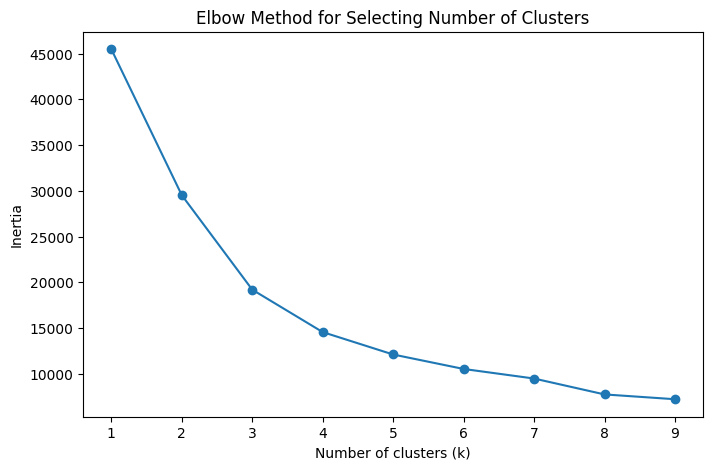

In [ ]:
inertia_values = []

k_values = range(1, 10)

for k in k_values:
    kmeans_temp = KMeans(n_clusters=k, random_state=42)
    kmeans_temp.fit(scaled_features)
    inertia_values.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia_values, marker="o")
plt.title("Elbow Method for Selecting Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.show()

## Silhouette score analysis

In [ ]:
silhouette_scores = []

k_values = range(2, 10)

for k in k_values:
    kmeans_temp = KMeans(n_clusters=k, random_state=42)
    labels = kmeans_temp.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels)
    silhouette_scores.append(score)

silhouette_df = pd.DataFrame({
    "k": list(k_values),
    "Silhouette Score": silhouette_scores
})

silhouette_df

,k,Silhouette Score
0,2,0.427065
1,3,0.490853
2,4,0.452674
3,5,0.471420
4,6,0.472772
5,7,0.469103
6,8,0.481925
7,9,0.468790


### Applying K-Means Clustering

After the data was standardized, K-means clustering was applied to identify groups of leads with similar engagement behavior.

In [ ]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(scaled_features)

cluster_df["Cluster"] = clusters

### Inspecting Cluster Distribution

After the clustering process, the distribution of observations across the clusters was examined.

In [ ]:
cluster_df["Cluster"].value_counts()

,count
Cluster,
1,5332
0,2308
2,1457


## PCA-Based Cluster Visualisation

In [ ]:
pca = PCA(n_components=2)

pca_components = pca.fit_transform(scaled_features)

cluster_df["PCA1"] = pca_components[:, 0]
cluster_df["PCA2"] = pca_components[:, 1]

explained_variance = pca.explained_variance_ratio_

print("Explained variance ratio:")
print(f"PCA1: {explained_variance[0]:.2%}")
print(f"PCA2: {explained_variance[1]:.2%}")
print(f"Total explained variance: {explained_variance.sum():.2%}")

Explained variance ratio:
PCA1: 54.07%
PCA2: 34.56%
Total explained variance: 88.62%


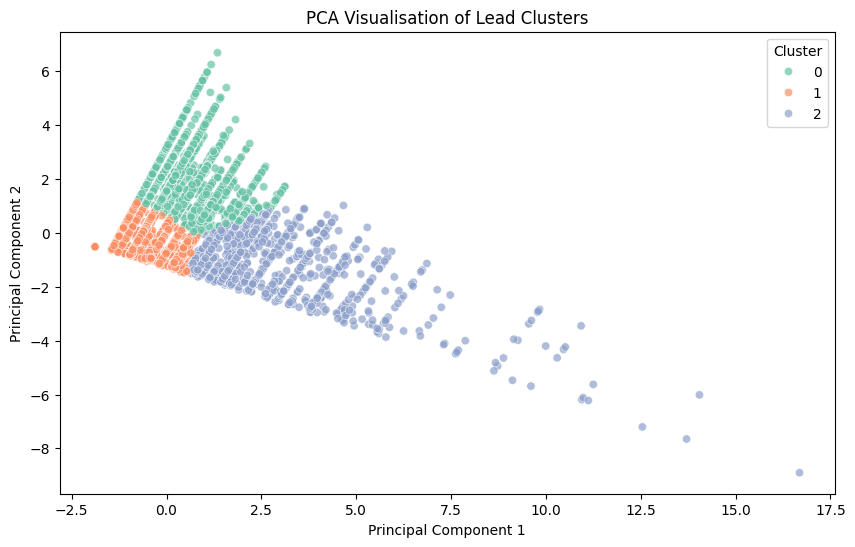

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=cluster_df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set2",
    alpha=0.7
)

plt.title("PCA Visualisation of Lead Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

### Analyzing Cluster Characteristics

After assigning cluster labels to each observation, the average values for each variable within each cluster were calculated.

In [ ]:
cluster_profile = cluster_df.groupby("Cluster")[
    [
        "TotalVisits",
        "Total Time Spent on Website",
        "Page Views Per Visit",
        "EngagementScore",
        "TimePerVisit",
        "Converted"
    ]
].mean()

cluster_profile["Conversion Rate (%)"] = (
    cluster_profile["Converted"] * 100
)

cluster_profile = cluster_profile.drop(columns=["Converted"])

cluster_profile

,TotalVisits,Total Time Spent on Website,Page Views Per Visit,EngagementScore,TimePerVisit,Conversion Rate (%)
Cluster,,,,,,
0,3.535529,1245.467504,2.650360,10.189159,309.331967,67.244367
1,1.821830,135.938485,1.385458,4.615844,36.990430,25.825206
2,8.804393,534.209334,5.419856,46.748572,57.734746,36.376115


In [ ]:
prioritisation_strategy = pd.DataFrame({
    "Cluster": [0, 1, 2],
    "Segment Interpretation": [
        "High-engagement leads",
        "Low-engagement leads",
        "Medium / deep-interest leads"
    ],
    "Business Priority": [
        "High",
        "Low",
        "Medium"
    ],
    "Suggested CRM Action": [
        "Immediate sales follow-up",
        "Automated nurturing or awareness campaigns",
        "Targeted nurturing and monitoring"
    ]
})

prioritisation_strategy

,Cluster,Segment Interpretation,Business Priority,Suggested CRM Action
0,0,High-engagement leads,High,Immediate sales follow-up
1,1,Low-engagement leads,Low,Automated nurturing or awareness campaigns
2,2,Medium / deep-interest leads,Medium,Targeted nurturing and monitoring


### Visualizing Lead Segments

To better understand the relationship between website engagement and the identified lead segments, a scatterplot visualization was created.

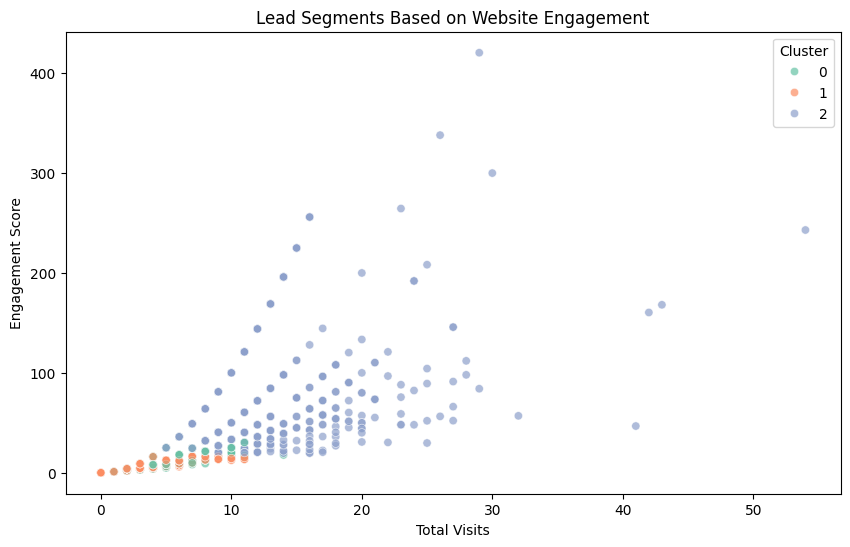

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=cluster_df,
    x="TotalVisits",
    y="EngagementScore",
    hue="Cluster",
    palette="Set2",
    alpha=0.7
)

plt.title("Lead Segments Based on Website Engagement")

plt.xlabel("Total Visits")
plt.ylabel("Engagement Score")

plt.show()

## Lead Segmentation Analysis

The clustering visualization illustrates three distinct lead segments identified using K-Means clustering based on website engagement behavior.

The analysis used the following features:

- TotalVisits
- Total Time Spent on Website
- Page Views Per Visit
- EngagementScore
- TimePerVisit

The x-axis represents the number of website visits, while the y-axis represents the engineered EngagementScore, which combines visit frequency and browsing depth.

### Cluster Interpretations

### Cluster 1 — Low-Engagement Leads (Orange)
This cluster represents leads with:
- Very few website visits
- Low engagement scores
- Limited browsing activity

These leads demonstrate weak interaction behavior and are considered low-priority from a business perspective. Marketing efforts toward this segment may require broad awareness campaigns rather than direct sales follow-up.

---

### Cluster 0 — High-Engagement Leads (Green)
This cluster represents highly engaged leads characterized by:
- Frequent website visits
- High page-view activity
- Strong overall engagement behavior

These leads are likely to have stronger conversion potential and should be prioritized by marketing and sales teams for immediate follow-up and personalized outreach.

---

### Cluster 2 — Medium / Deep-Interest Leads (Blue)
This cluster represents leads with:
- Moderate visit frequency
- Significantly longer session durations
- Higher engagement intensity per visit

Although these users visit the website less frequently than Cluster 0, they spend substantially more time during each session. This behavior may indicate focused research activity and high purchase intent.

From a business perspective, these leads may benefit from nurturing strategies, educational content, or targeted recommendations before direct sales contact.

---

Overall, the clustering analysis demonstrates that lead behavior is not uniform across the dataset. Different lead segments exhibit distinct engagement patterns, supporting differentiated prioritisation strategies within CRM systems.

### Percentage of conversion per cluster

In [ ]:
cluster_df["Converted"] = df.loc[cluster_df.index, "Converted"]

cluster_conversion = (
    cluster_df.groupby("Cluster")["Converted"]
    .mean()
    * 100
)

cluster_conversion

,Converted
Cluster,
0,67.244367
1,25.825206
2,36.376115


From a business perspective, this analysis provides insight into which marketing channels contribute to high-value lead segments. This can support CRM prioritisation strategies and help organizations allocate marketing resources more effectively.

In [ ]:
cluster_df["Lead Source"] = df.loc[cluster_df.index, "Lead Source"]

pd.crosstab(
    cluster_df["Cluster"],
    cluster_df["Lead Source"]
)

Lead Source,Click2call,Direct Traffic,Facebook,Google,Live Chat,NC_EDM,Olark Chat,Organic Search,Pay per Click Ads,Press_Release,...,Referral Sites,Social Media,WeLearn,Welingak Website,bing,blog,google,testone,welearnblog_Home,youtubechannel
Cluster,,,,,,,,,,,,,,,,,,,,,
0,1,809,0,1066,0,1,64,302,0,0,...,26,1,1,6,0,1,2,0,0,0
1,2,1315,30,1294,2,0,1672,386,1,0,...,56,1,0,122,6,0,1,1,1,1
2,1,415,1,508,0,0,17,465,0,2,...,42,0,0,1,0,0,2,0,0,0
